<a href="https://colab.research.google.com/github/sunithamacharla8978-cyber/ADS/blob/main/2503b05125.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install torch torchvision matplotlib numpy


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

batch_size = 128

transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    transform=transform,
    download=True
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


100%|██████████| 9.91M/9.91M [00:00<00:00, 22.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 661kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 5.67MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.00MB/s]


In [4]:
class Encoder(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x):
        h = torch.relu(self.fc1(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar


In [5]:
def reparameterize(mu, logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + eps * std


In [6]:
class Decoder(nn.Module):
    def __init__(self, latent_dim=20, hidden_dim=400, output_dim=784):
        super().__init__()
        self.fc1 = nn.Linear(latent_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, z):
        h = torch.relu(self.fc1(z))
        x_hat = torch.sigmoid(self.fc2(h))
        return x_hat


In [7]:
def vae_loss(x, x_hat, mu, logvar):
    # Reconstruction loss (Bernoulli likelihood)
    recon_loss = nn.functional.binary_cross_entropy(
        x_hat, x, reduction='sum'
    )

    # KL divergence
    kl_div = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    return recon_loss + kl_div


In [8]:
class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = reparameterize(mu, logvar)
        x_hat = self.decoder(z)
        return x_hat, mu, logvar


In [10]:
model = VAE().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

epochs = 20

for epoch in range(epochs):
    model.train()
    train_loss = 0

    for x, _ in train_loader:
        x = x.view(-1, 784).to(device)

        optimizer.zero_grad()
        x_hat, mu, logvar = model(x)
        loss = vae_loss(x, x_hat, mu, logvar)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_loss = train_loss / len(train_loader.dataset)
    print(f"Epoch [{epoch+1}/{epochs}] Loss: {avg_loss:.4f}")


Epoch [1/20] Loss: 164.0284
Epoch [2/20] Loss: 121.5208
Epoch [3/20] Loss: 114.6581
Epoch [4/20] Loss: 111.6580
Epoch [5/20] Loss: 109.9850
Epoch [6/20] Loss: 108.8559
Epoch [7/20] Loss: 107.9485
Epoch [8/20] Loss: 107.3553
Epoch [9/20] Loss: 106.8373
Epoch [10/20] Loss: 106.4075
Epoch [11/20] Loss: 106.0499
Epoch [12/20] Loss: 105.7006
Epoch [13/20] Loss: 105.4357
Epoch [14/20] Loss: 105.1945
Epoch [15/20] Loss: 104.9806
Epoch [16/20] Loss: 104.8126
Epoch [17/20] Loss: 104.6039
Epoch [18/20] Loss: 104.3753
Epoch [19/20] Loss: 104.3041
Epoch [20/20] Loss: 104.1198


In [11]:
torch.save(model.state_dict(), "vae_mnist.pth")


In [12]:
model.eval()

with torch.no_grad():
    z = torch.randn(64, 20).to(device)
    samples = model.decoder(z)
    samples = samples.view(-1, 1, 28, 28).cpu()


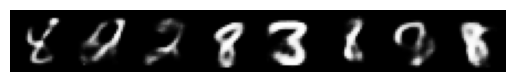

In [13]:
def show_images(images):
    grid = np.transpose(
        torch.cat([img for img in images], dim=2).numpy(),
        (1, 2, 0)
    )
    plt.imshow(grid, cmap="gray")
    plt.axis("off")
    plt.show()

show_images(samples[:8])


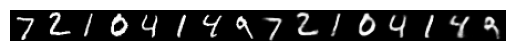

In [14]:
x, _ = next(iter(test_loader))
x = x.view(-1, 784).to(device)

with torch.no_grad():
    x_hat, _, _ = model(x)

comparison = torch.cat([x[:8], x_hat[:8]])
comparison = comparison.view(-1, 1, 28, 28).cpu()
show_images(comparison)
